# Debugging Notebook for functions

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
from encoding import *
from processing import *
from decoding import *
from visualize import *
from trainer import *
from mesh import *
from baseline import *
from metrics import *
#from main import *
import numpy as np
import matplotlib.pyplot as plt

# Loading data from mnist set
Functions in encoding.py

7
Number of '7' in this set: 48, number of '1' in this set: 62


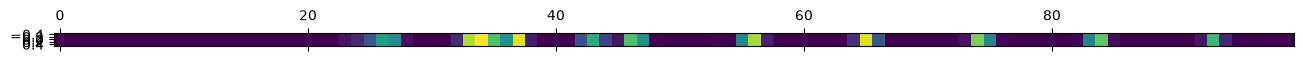

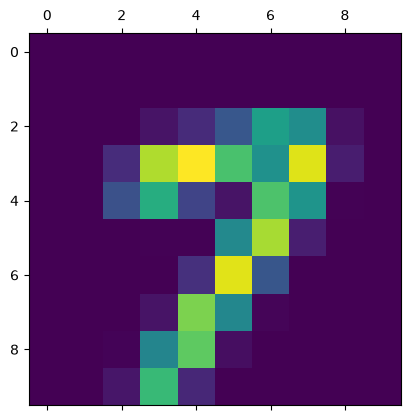

In [4]:
values = np.array([1,7]) #figures you want from the mnist dataset
mode = "Testing" #Selects if you want the test-set ("Testing") or the training-set ("Training")
number = 110 #Sets number of samples you want to get in total
m_side = 10 #side length (pixel) of mnist image after downsampling
theta_enc = 1 #mysterious hyper parameter for amplitude scaling
norm_energy = True #Bool for if energy of encoded image should be normalized or not
seed = None #Random seed to control random choice of number -pictures out of the available ones, 
            #seed = None leads to random results for each iteration

E_X, Y = get_data(values, mode, number, m_side, theta_enc, norm_energy, seed) #E_X are the flattened arrays of the encoded mnist images (complex valued), 
                                                                  #Y are the referring labels
#Example of the first entry
plt.matshow(np.real(E_X[:,0]).reshape(1, -1), ) #reshaping it just for plotting with plt.matshow
plt.matshow(np.real(E_X[:,0]).reshape(m_side,m_side))
print(Y[0])

print("Number of '7' in this set: " + str(np.sum(Y == 7))+", number of '1' in this set: " + str(np.sum(Y == 1)))


# Initializing MZI-Mesh
Functions in mesh.py
(No parameter initialization yet)

Number of layers in the setup: 4
MZIs along the layers in the setup: [2, 1, 2, 1]
Total number of (trainable) MZIs in the setup: 6


<Axes: title={'center': 'N=4, 4 Layer, 6 MZIs'}, xlabel='Layer', ylabel='Channel'>

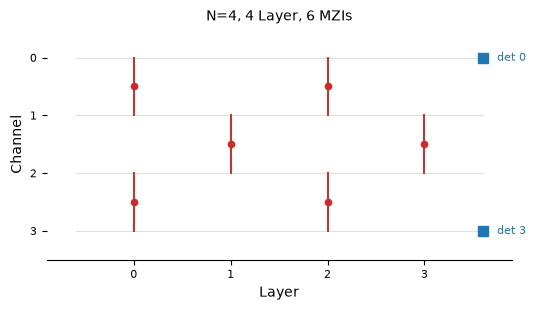

In [5]:
N=4 #Number of channels
L=4 #Number of layers
test_plan = plan_rectangular(N, L) #other plans are plan_redundant and plan_triangular
test_mesh = MZIMesh(N, test_plan) #Object containing the geometry of the MZI-Mesh

#Each mesh object carries its properties:
n_layers = test_mesh.n_layers
n_slots = test_mesh.slot_counts
n_mzis = test_mesh.n_mzis
print(f"Number of layers in the setup: {n_layers}") #layers of setup
print(f"MZIs along the layers in the setup: {n_slots}") #distribution of MZIs along the layers
print(f"Total number of (trainable) MZIs in the setup: {n_mzis}") #number of (trainable MZIs in this setup)


plot_mesh(test_mesh, color_by=None, detectors=[0, 3], label_step=None) #function of visualize.py to show the geometry (and detectors)


# Initializing Mesh parameters
Functions in mesh.py, here just init_random, also init_haar already coded (later used)

Phis: [array([4.9088384 , 4.16593245]), array([2.07575098]), array([1.62054033, 4.53554834]), array([0.70421367])]
Thetas: [array([1.43946645, 1.18035091]), array([3.02045461]), array([1.40148359, 0.76404964]), array([1.1120134])]


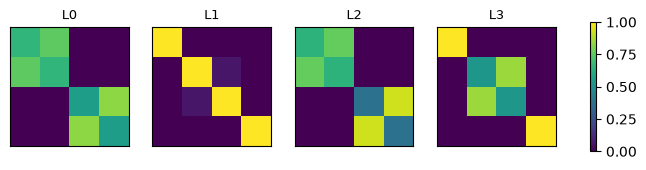

In [6]:
thetas, phis = test_mesh.init_random()
print(f"Phis: {phis}")
print(f"Thetas: {thetas}")

layers = test_mesh.layer_matrices(thetas, phis)   #building layers (transfer matrices) out of the parameters
fig, _ = plot_layers(layers, mode="Abs")


# Propagation

[[ 0.0087173 -0.0074286j   0.01087472-0.01479373j -0.01327434-0.04131715j
  ... -0.0398168 -0.06600372j  0.02452705-0.03351177j
   0.01458934-0.00741095j]
 [ 0.0178122 +0.0220473j   0.03017313-0.02786248j  0.04283379-0.01597734j
  ...  0.04420755-0.00815614j  0.01321675-0.03470165j
   0.00091119+0.02341521j]
 [-0.01177667+0.01550092j -0.0095778 -0.00592776j -0.00179377-0.00881075j
  ...  0.00404074-0.01874456j -0.01781828-0.0094991j
  -0.0080753 +0.00457779j]
 ...
 [ 0.01446716+0.07405818j -0.02037691+0.04869702j  0.0113405 +0.01053371j
  ...  0.00521505-0.00143836j -0.00926104+0.06326049j
   0.0126712 -0.02666322j]
 [-0.00177207+0.00888316j -0.00482229+0.04864321j  0.01396242+0.00151309j
  ...  0.00777505+0.01195474j  0.00740074+0.06560748j
   0.03149574-0.01425919j]
 [ 0.1137768 +0.05097833j  0.06370897-0.01860148j  0.0488475 -0.00783137j
  ... -0.00786528+0.02804794j  0.07053746-0.0157413j
   0.04678715+0.03249438j]]
(100, 110)
[[[ 0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00

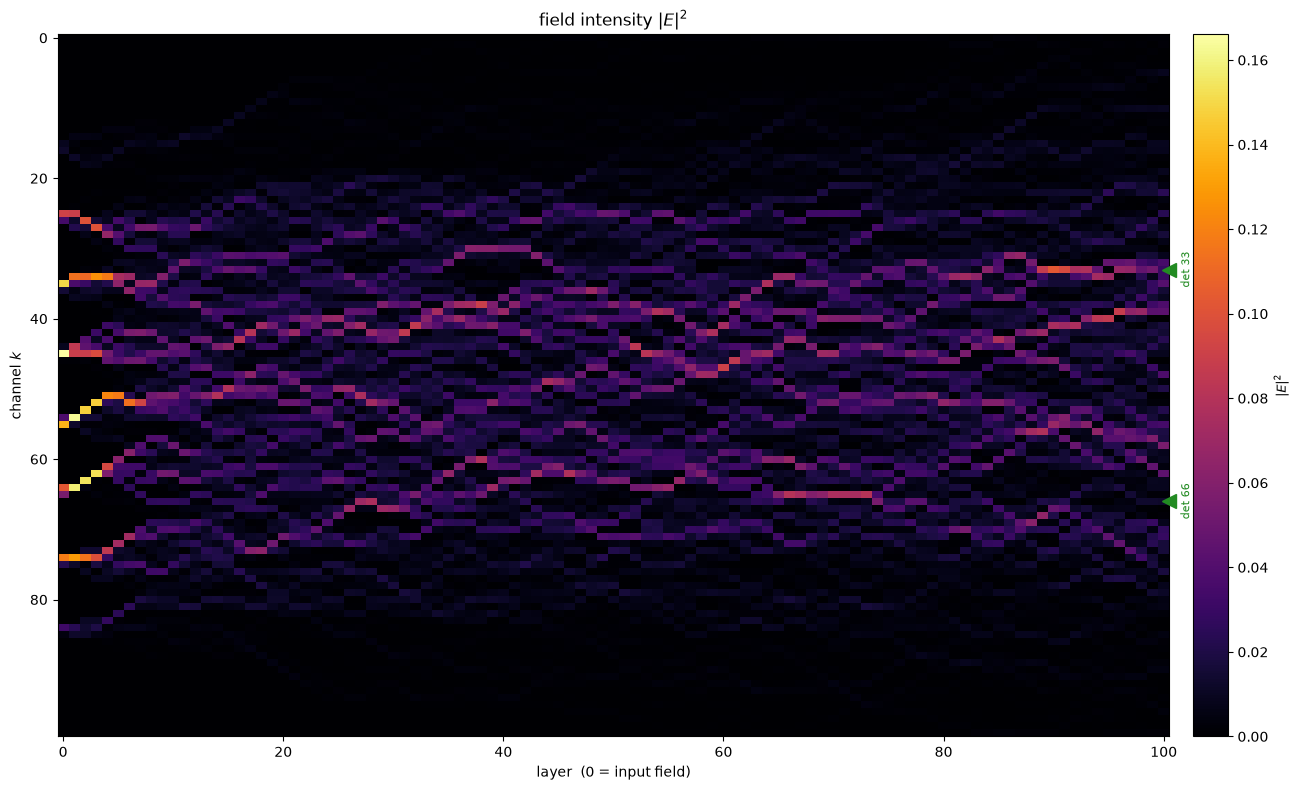

In [7]:
N=100 #number of channels (number of pixels in mnist image)
prop_mesh = MZIMesh(N, plan_rectangular(N, N)) #creating mesh object
thetas, phis = prop_mesh.init_random() #initializing random weights

layers = prop_mesh.layer_matrices(thetas, phis)   #build transfer matrices (layers) from parameters

E_out  = forward(E_X, layers)         #propagation that gives end result directly
print(E_out)                          #format: [channels, batches]
print(np.shape(E_out))

E_hist = forward_history(E_X, layers) #propagation that gives all E-fields for every layer
print(E_hist)                         #format: [layers, channels, batches]
print(np.shape(E_hist))
I = np.abs(E_hist[:,:,2])**2
fig, _ = plot_intensity_map(I, detectors=[33,66])

[]

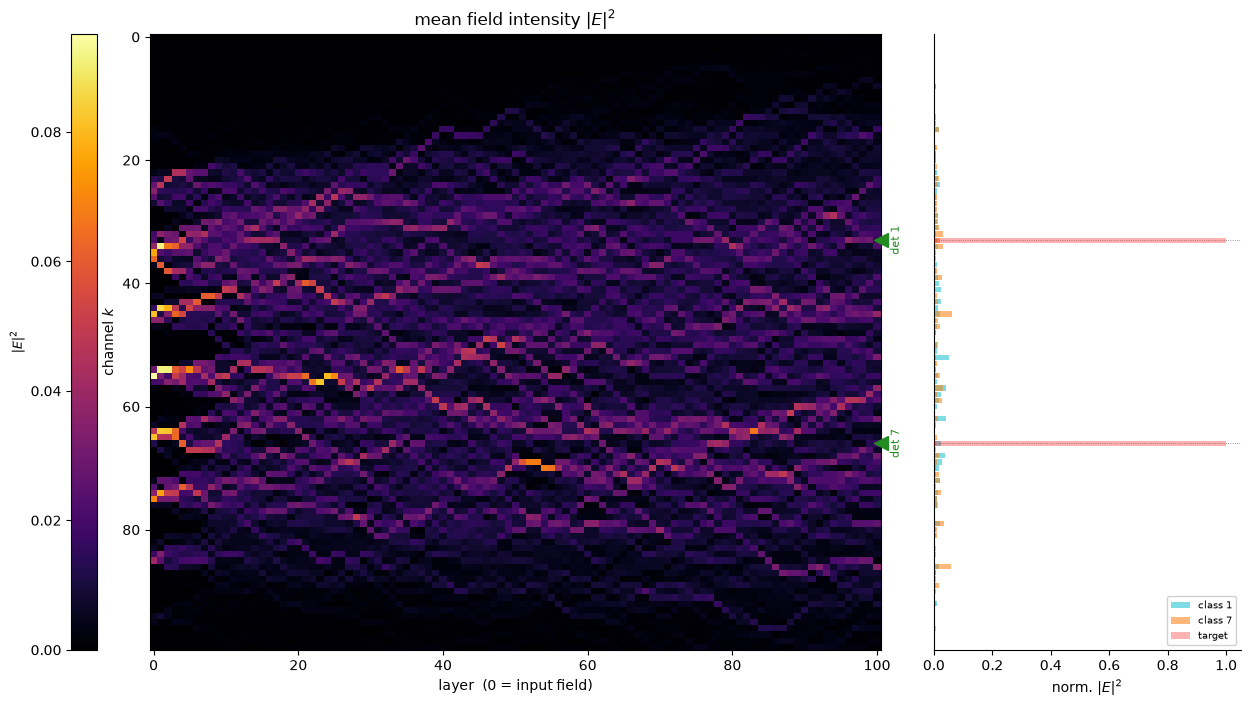

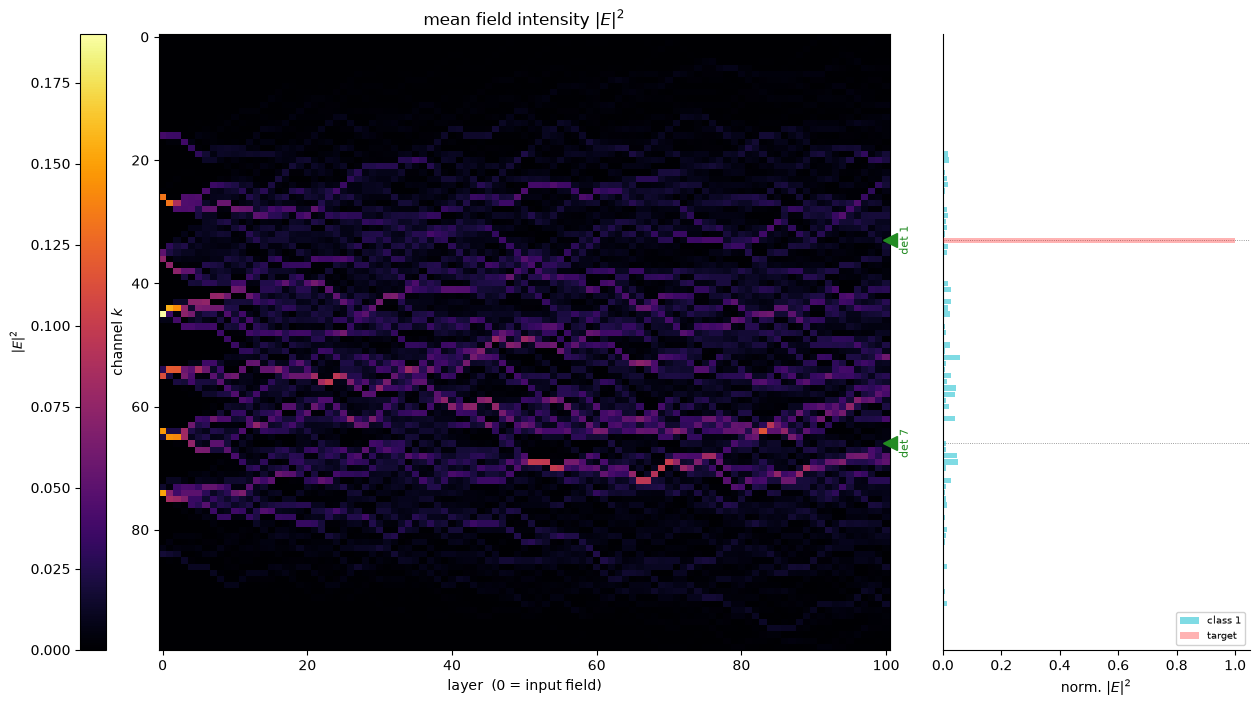

In [ ]:
fig, _ = plot_intensity_map_with_histogram(np.abs(E_hist[:,:,1:10])**2, det1=33, det7=66, Y=Y[1:10])
plt.plot()
fig, _ = plot_intensity_map_with_histogram(np.abs(E_hist[:,:,36])**2, det1=33, det7=66, Y=Y[36])
plt.plot()

In [8]:
loss_norm=loss_function(E_hist, Y, 33, 66, kind="mse_norm" )
loss=loss_function(E_hist, Y, 33, 66, kind="mse" )


# Linear regression
## m = 10
### No normalized energy

In [13]:
values = np.array([1,7]) #figures you want from the mnist dataset
mode = "Testing" #Selects if you want the test-set ("Testing") or the training-set ("Training")
number = None #Sets number of samples you want to get in total
m = 10 #side length (pixel) of mnist image after downsampling
theta_enc = 1 #mysterious hyper parameter for amplitude scaling
norm_energy = False #Bool for if energy of encoded image should be normalized or not
seed = None #Random seed to control random choice of number -pictures out of the available ones, 
            #seed = None leads to random results for each iteration

E_X_Train, Y_Train = get_data(values, "Training", number, m, theta_enc, norm_energy, seed) #E_X are the flattened arrays of the encoded mnist images (complex valued), 
                                                                  #Y are the referring labels
print(np.shape(E_X_Train))
E_X_Test, Y_Test = get_data(values, "Testing", number, m, theta_enc, norm_energy, seed) #E_X are the flattened arrays of the encoded mnist images (complex valued), 
                                                                  #Y are the referring labels

theta, y_pred, accuracy_val, conf_matrix = linear_regression(E_X_Train.T, Y_Train, E_X_Test.T, Y_Test)
print(accuracy_val)

(100, 13007)
0.984743411927878


### Normalized energy

In [25]:
values = np.array([1,7]) #figures you want from the mnist dataset
mode = "Testing" #Selects if you want the test-set ("Testing") or the training-set ("Training")
number = None #Sets number of samples you want to get in total
m = 10 #side length (pixel) of mnist image after downsampling
theta_enc = 1 #mysterious hyper parameter for amplitude scaling
norm_energy = True #Bool for if energy of encoded image should be normalized or not
seed = None #Random seed to control random choice of number -pictures out of the available ones, 
            #seed = None leads to random results for each iteration

E_X_Train, Y_Train = get_data(values, "Training", number, m, theta_enc, norm_energy, seed) #E_X are the flattened arrays of the encoded mnist images (complex valued), 
                                                                  #Y are the referring labels
#plt.matshow(np.real(E_X_Train[:,2]).reshape((28,28)))
E_X_Test, Y_Test = get_data(values, "Testing", number, m, theta_enc, norm_energy, seed) #E_X are the flattened arrays of the encoded mnist images (complex valued), 
                                                                  #Y are the referring labels

theta, y_pred, accuracy_val, conf_matrix = linear_regression(E_X_Train.T, Y_Train, E_X_Test.T, Y_Test)
print(accuracy_val)

0.9921405455386038


## Sweep over m
With normalized energy

In [28]:
print(np.size(np.arange(1,29,1)))

28


0.5247341655108645
0.8118354137771614
0.9662505779010634
0.9680998613037448
0.9884419787332409
0.9907535829865927
0.9916782246879334
0.9879796578825705
0.9907535829865927
0.9921405455386038
0.9926028663892742
0.9884419787332409
0.9907535829865927
0.9921405455386038
0.9907535829865927
0.9893666204345816
0.9889042995839112
0.989828941285252
0.989828941285252
0.9912159038372631
0.9902912621359223
0.9889042995839112
0.989828941285252
0.9889042995839112
0.9902912621359223
0.9902912621359223
0.9889042995839112
0.989828941285252


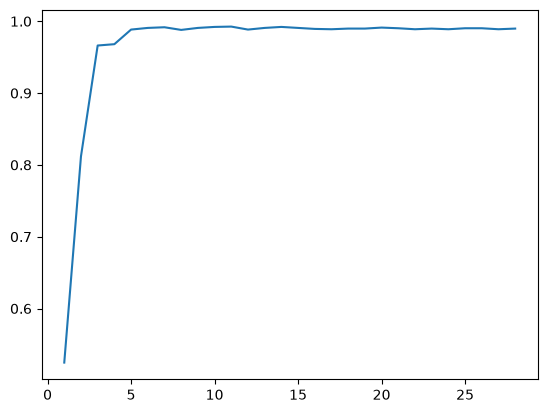

In [ ]:
values = np.array([1,7]) #figures you want from the mnist dataset
mode = "Testing" #Selects if you want the test-set ("Testing") or the training-set ("Training")
number = None #Sets number of samples you want to get in total

m_sweep = np.arange(1,29,1) #sweeping over side length (pixel) of mnist image (1 to 28)
accuracies_sweep = np.zeros(28)

theta_enc = 1 #mysterious hyper parameter for amplitude scaling
norm_energy = True #Bool for if energy of encoded image should be normalized or not
seed = None #Random seed to control random choice of number -pictures out of the available ones, 
            #seed = None leads to random results for each iteration
for i,m in enumerate(m_sweep):
    E_X_Train, Y_Train = get_data(values, "Training", number, m, theta_enc, norm_energy, seed) #E_X are the flattened arrays of the encoded mnist images (complex valued), 
                                                                    #Y are the referring labels
    #plt.matshow(np.real(E_X_Train[:,2]).reshape((28,28)))
    E_X_Test, Y_Test = get_data(values, "Testing", number, m, theta_enc, norm_energy, seed) #E_X are the flattened arrays of the encoded mnist images (complex valued), 
                                                                    #Y are the referring labels

    theta, y_pred, accuracy_val, conf_matrix = linear_regression(E_X_Train.T, Y_Train, E_X_Test.T, Y_Test)
    print(accuracy_val)
    accuracies_sweep[i]=accuracy_val.copy()

plt.plot(m_sweep, accuracies_sweep)

[[1132    3]
 [  19 1009]]


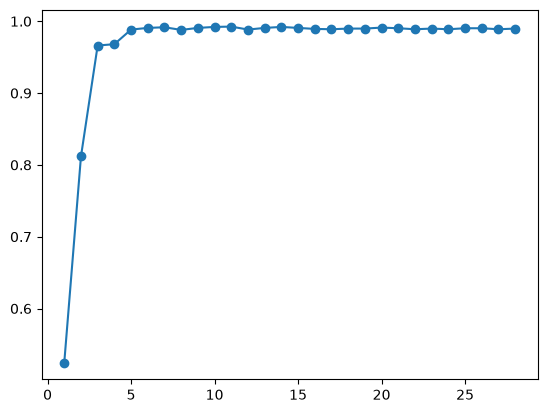

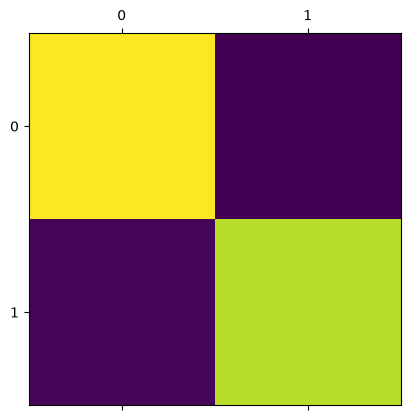

In [ ]:
print(conf_matrix)
plt.plot(m_sweep, accuracies_sweep, marker="o")

Training: 1000 samples, class counts {1: 500, 7: 500}
Testing: 1000 samples, class counts {1: 500, 7: 500}
0.775


ValueError: x and y must have same first dimension, but have shapes (1,) and (28,)

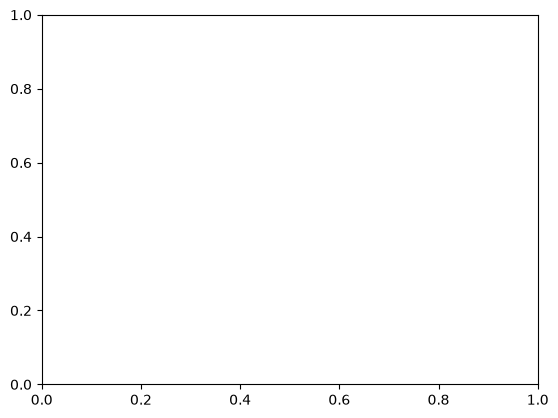

In [ ]:
values = np.array([1,7]) #figures you want from the mnist dataset
mode = "Testing" #Selects if you want the test-set ("Testing") or the training-set ("Training")
number = 1000 #Sets number of samples you want to get in total


m_sweep = [1] #sweeping over side length (pixel) of mnist image (1 to 28)
accuracies_sweep = np.zeros(28)

theta_enc = 1 #mysterious hyper parameter for amplitude scaling
norm_energy = False #Bool for if energy of encoded image should be normalized or not
seed = None #Random seed to control random choice of number -pictures out of the available ones, 
            #seed = None leads to random results for each iteration
for i,m in enumerate(m_sweep):
    E_X_Train, Y_Train = get_data(values, "Training", number, m, theta_enc, norm_energy, seed, balanced=True, verbose=True) #E_X are the flattened arrays of the encoded mnist images (complex valued), 
                                                                    #Y are the referring labels
    #plt.matshow(np.real(E_X_Train[:,2]).reshape((28,28)))
    E_X_Test, Y_Test = get_data(values, "Testing", number, m, theta_enc, norm_energy, seed, balanced=True, verbose=True) #E_X are the flattened arrays of the encoded mnist images (complex valued), 
                                                                    #Y are the referring labels

    theta, y_pred, accuracy_val, conf_matrix = linear_regression(E_X_Train.T, Y_Train, E_X_Test.T, Y_Test)
    print(accuracy_val)
    accuracies_sweep[i]=accuracy_val.copy()


## Plotting intensity-differences between 7 and 1

In [ ]:
values = np.array([1,7]) #figures you want from the mnist dataset
mode = "Testing" #Selects if you want the test-set ("Testing") or the training-set ("Training")
number = None #Sets number of samples you want to get in total
m = 10 #side length (pixel) of mnist image after downsampling
theta = 1 #mysterious hyper parameter for amplitude scaling
norm_energy = False #Bool for if energy of encoded image should be normalized or not
seed = None #Random seed to control random choice of number -pictures out of the available ones, 
            #seed = None leads to random results for each iteration

E_X_Train, Y_Train = get_data(values, "Training", number, m, theta, norm_energy, seed) #E_X are the flattened arrays of the encoded mnist images (complex valued), 
                                                                  #Y are the referring labels

E_X_Test, Y_Test = get_data(values, "Testing", number, m, theta, norm_energy, seed) #E_X are the flattened arrays of the encoded mnist images (complex valued), 
                                                                  #Y are the referring labels


(100, 13007)


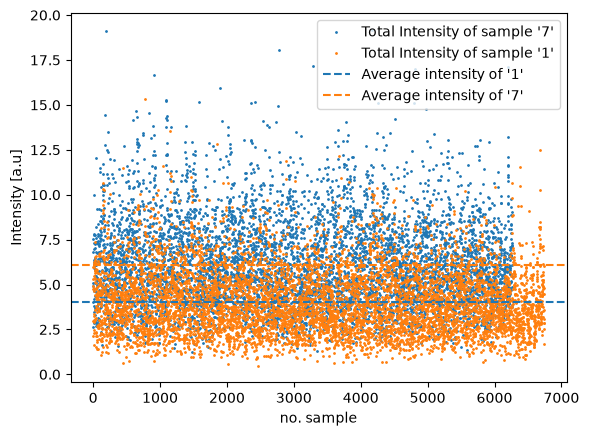

In [ ]:
print(np.shape(E_X_Train))
mask7 = Y_Train==7
mask1 = Y_Train==1

sumIntensity7 = np.sum(np.abs(E_X_Train[:,mask7])**2, axis=0)
sumIntensity1 = np.sum(np.abs(E_X_Train[:,mask1])**2, axis=0)
avgIntensity7 = np.mean(sumIntensity7)
avgIntensity1 = np.mean(sumIntensity1)
plt.plot(sumIntensity7, color="tab:blue", label="Total Intensity of sample '7'", linewidth=0.0, marker="o", markersize=1)
plt.plot(sumIntensity1, color="tab:orange", label="Total Intensity of sample '1'", linewidth=0.0, marker="o", markersize=1)
plt.axhline(y=avgIntensity1, color="tab:blue", linestyle="--", label="Average intensity of '1'")
plt.axhline(y=avgIntensity7, color="tab:orange", linestyle="--", label="Average intensity of '7'")
plt.ylabel("Intensity [a.u]")
plt.xlabel("no. sample")
plt.legend()

# O